### Replicating Note segmentation

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import soundfile as sf
import matplotlib.pyplot as plt


In [2]:
ref_file = Path("05_Antonio Mairena_Verguenza")
gt_folder = Path("../data/cante2midi_groundTruth")
f0auto_folder = Path("../data/cante2midi_f0")
bark_bands_folder = Path("../data/cante2midi_bakbands")
audio_folder = Path("../data/cante2midiaudio")
spec_folder = Path("../data/cante2midi_spectrum")
PESTO_f0_folder = Path("f0Contour_PESTO")

wav, sr = sf.read(str(audio_folder/ref_file.with_suffix(".wav")))
print(f"Audio loaded ! Samples = {len(wav)}    Dur = {(len(wav)/sr):.2f} sec. (sf={sr})")


f0_contour = pd.read_csv(f0auto_folder/ref_file.with_suffix(".f0.csv"), names = ['time', 'f0'])

bark_bands = pd.read_csv(bark_bands_folder/ref_file.with_suffix(".barkbands.csv"),
                         sep=" ",
                         names= [0.0, 50.0, 100.0, 150.0, 200.0, 300.0, 400.0, 510.0, 630.0, 770.0, 920.0, 1080.0, 1270.0, 1480.0, 1720.0, 2000.0, 2320.0, 2700.0, 3150.0, 3700.0, 4400.0, 5300.0, 6400.0, 7700.0, 9500.0, 12000.0, 15500.0, 20500.0, 27000.0])
spec = pd.read_csv(spec_folder/ref_file.with_suffix(".spectrum.csv"),
                   sep=" ",
                   header =None)

pesto_pred = pd.read_csv(PESTO_f0_folder/ref_file.with_suffix(".f0.csv"))
#vocal_contour = filter_vocal_contour(f0_contour['freq'], bark_energies=bark_bands[bark_bands.columns[:12]])

Audio loaded ! Samples = 4716288    Dur = 106.95 sec. (sf=44100)


/home/ibroto/anaconda3/envs/flamencoMIRf0/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


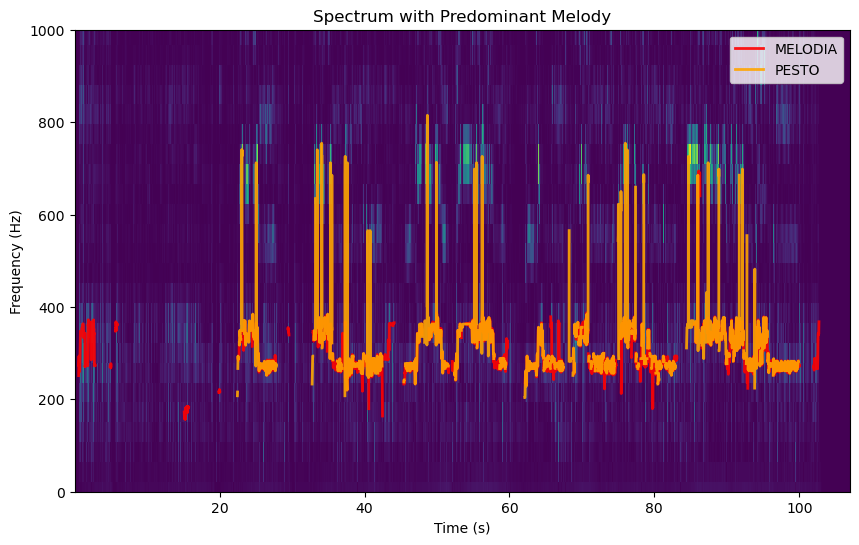

In [3]:
# first column is time
spec_time = spec.iloc[:,0].values
spec_mag = spec.iloc[:,1:].values

# frequency axis
sr = 44100
n_fft = 1024
freqs = np.linspace(0, sr/2, spec_mag.shape[1])

plt.figure(figsize=(10,6))

# spectrogram
plt.pcolormesh(spec_time, freqs, spec_mag.T, shading="auto")

# remove unvoiced frames
f0_plot = f0_contour.copy()
f0_plot.loc[f0_plot.f0 <= 0, "f0"] = np.nan
f0PESTO_plot = pesto_pred.copy()
f0PESTO_plot.loc[f0PESTO_plot.f0_hz<= 0, "f0_hz"] = np.nan

# overlay melody
plt.plot(f0_plot.time, f0_plot.f0, color="red", linewidth=2, label="MELODIA", alpha = 0.9)

plt.plot(f0PESTO_plot.time_sec, f0PESTO_plot.f0_hz, color="orange", linewidth=2, label ="PESTO", alpha=0.9)

plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Spectrum with Predominant Melody")
plt.ylim(0,1000)
plt.legend()
plt.show()

## Melody extraction with MELODIA

In [4]:
import essentia
import essentia.standard as es
import numpy as np

# Load audio
loader = es.MonoLoader(filename=str(audio_folder/ref_file.with_suffix(".wav")), sampleRate=44100)
audio = loader()


# Create pitch extractor
pitch_extractor = es.MultiPitchMelodia(
    sampleRate=44100,
    frameSize=1024,
    hopSize=128,
    minFrequency=120,
    maxFrequency=720,
    #v=0.2,
)

# Run algorithm
pitches = pitch_extractor(audio)   # vector<vector<float>>

pitches = np.array(pitches, dtype=object)

# Time axis
hop_size = 128
sr = 44100
times = np.arange(len(pitches)) * hop_size / sr

print("Frames:", len(pitches))
print("Example frame:", pitches[0])

pitch_trace = np.array([
    frame[0] if len(frame) > 0 else 0
    for frame in pitches
])


melodia_trace = pd.DataFrame({
    "time": times,
    "pitch_hz": pitch_trace
})

melodia_trace.loc[melodia_trace.pitch_hz <= 0, "pitch_hz"] = np.nan

#melodia_trace.to_csv("pitch_trace.csv", index=False)


[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


Frames: 36847
Example frame: [0.]


In [5]:
melodia_trace

,time,pitch_hz
0,0.000000,NaN
1,0.002902,NaN
2,0.005805,NaN
3,0.008707,NaN
4,0.011610,NaN
...,...,...
36842,106.933696,NaN
36843,106.936599,NaN
36844,106.939501,NaN
36845,106.942404,NaN


/home/ibroto/anaconda3/envs/flamencoMIRf0/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


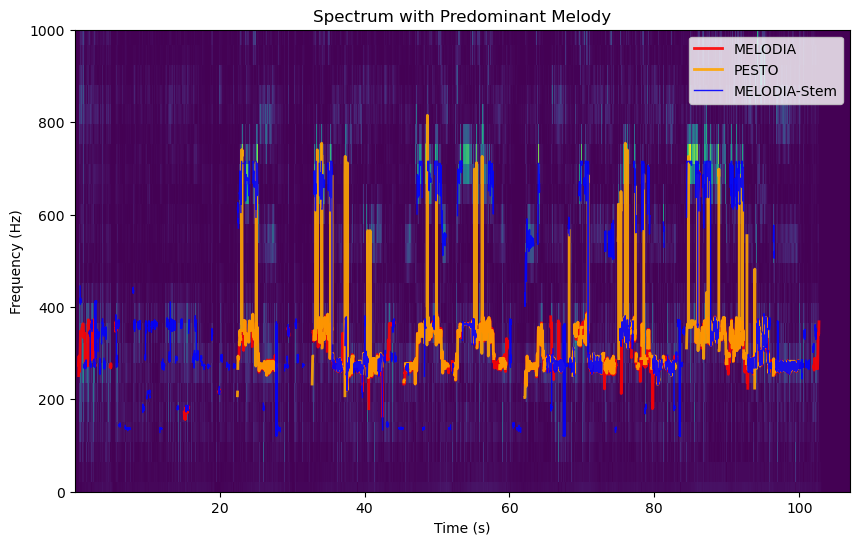

In [6]:
# first column is time
spec_time = spec.iloc[:,0].values
spec_mag = spec.iloc[:,1:].values

# frequency axis
sr = 44100
n_fft = 1024
freqs = np.linspace(0, sr/2, spec_mag.shape[1])

plt.figure(figsize=(10,6))

# spectrogram
plt.pcolormesh(spec_time, freqs, spec_mag.T, shading="auto")

# remove unvoiced frames
f0_plot = f0_contour.copy()
f0_plot.loc[f0_plot.f0 <= 0, "f0"] = np.nan
f0PESTO_plot = pesto_pred.copy()
f0PESTO_plot.loc[f0PESTO_plot.f0_hz<= 0, "f0_hz"] = np.nan

# overlay melody
plt.plot(f0_plot.time, f0_plot.f0, color="red", linewidth=2, label="MELODIA", alpha = 0.9)

plt.plot(f0PESTO_plot.time_sec, f0PESTO_plot.f0_hz, color="orange", linewidth=2, label ="PESTO", alpha=0.9)
plt.plot(melodia_trace.time, melodia_trace.pitch_hz, color="blue", linewidth=1, label ="MELODIA-Stem", alpha=0.9)

plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Spectrum with Predominant Melody")
plt.ylim(0,1000)
plt.legend()
plt.show()

## Onset Detection

### Interval Onsets 

In [7]:
f0 = pesto_pred[['time_sec','f0_hz']].copy()
f0.rename(columns={'time_sec':'time', 'f0_hz':'f0'}, inplace=True)
f0

f0 = f0_contour.copy()

In [8]:
import numpy as np

f_ref = 440
f0_valid = f0.copy()
f0_valid.loc[f0_valid.f0 <= 0, "f0"] = np.nan
cents = 1200 * np.log2(f0_valid.f0 / f_ref)


In [9]:
voiced = ~np.isnan(cents)

segments = []
current = []

for i,v in enumerate(voiced):
    if v:
        current.append(i)
    else:
        if current:
            segments.append(current)
            current = []

if current:
    segments.append(current)


In [10]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(cents)


In [11]:
interval_onsets = []

for i in range(len(peaks)-1):

    p1 = peaks[i]
    p2 = peaks[i+1]

    pitch_diff = abs(cents.iloc[p2] - cents.iloc[p1])
    time_diff = f0.time.iloc[p2] - f0.time.iloc[p1]

    if pitch_diff > 80 and time_diff < 0.25:

        onset = (p1 + p2) // 2
        interval_onsets.append(onset)

In [12]:
onset_times = f0.time.iloc[interval_onsets].values

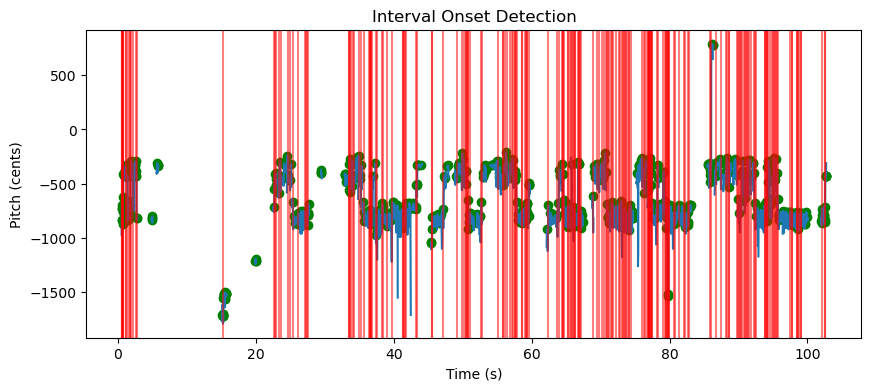

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(f0.time, cents)

plt.scatter(f0.time.iloc[peaks], cents.iloc[peaks], color="green")

for o in interval_onsets:
    plt.axvline(f0.time.iloc[o], color="red", alpha=0.5)

plt.ylabel("Pitch (cents)")
plt.xlabel("Time (s)")
plt.title("Interval Onset Detection")
plt.show()

### Gaussian Onsets

In [ ]:
hop = 128
sr = 44100

dt = hop / sr          # seconds per frame
sigma_s = 0.0435       # 43.5 ms
sigma = sigma_s / dt   # sigma in frames

filter_len_s = 0.3
Nh = int(filter_len_s / dt)
n = np.arange(-Nh//2, Nh//2)
h = -(n / sigma**2) * np.exp(-(n**2) / (2*sigma**2))

from scipy.signal import convolve

cF = convolve(cents, h, mode="same")
from scipy.signal import find_peaks

abs_cf = np.abs(cF)

peaks, _ = find_peaks(abs_cf, height=4.0)
gaussian_onsets = peaks
onset_times = f0.time.iloc[gaussian_onsets].values

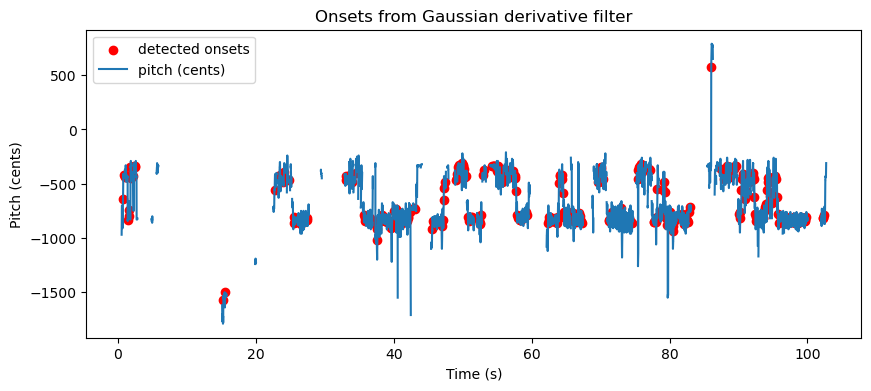

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))


plt.scatter(f0.time.iloc[gaussian_onsets],
            cents.iloc[gaussian_onsets],
            color="red",
            label="detected onsets")

plt.plot(f0.time, cents, label="pitch (cents)")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Pitch (cents)")
plt.title("Onsets from Gaussian derivative filter")
plt.show()

### Volume onsets

In [18]:
import librosa
import numpy as np

y, sr = librosa.load(audio_folder/ref_file.with_suffix(".wav"), sr=44100)

rms = librosa.feature.rms(
    y=y,
    frame_length=4096,
    hop_length=128
)[0]

In [19]:
import pandas as pd

rms_series = pd.Series(rms)

local_mean = rms_series.rolling(
    window=101,
    center=True
).mean()

rLOC = 20 * np.log10(rms_series / local_mean)

from scipy.signal import find_peaks

volume_onsets, _ = find_peaks(
    -rLOC,
    height=10
)

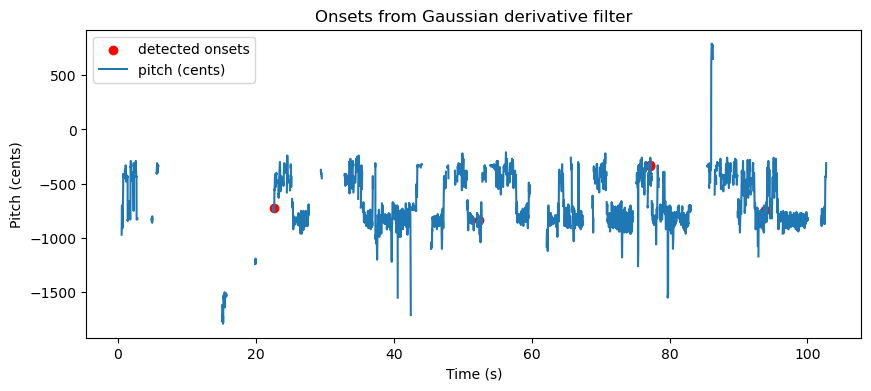

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))


plt.scatter(f0.time.iloc[volume_onsets],
            cents.iloc[volume_onsets],
            color="red",
            label="detected onsets")

plt.plot(f0.time, cents, label="pitch (cents)")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Pitch (cents)")
plt.title("Onsets from Gaussian derivative filter")
plt.show()

### pitch drop onsets

In [21]:
c = cents.values

mu = np.nanmean(c)
sigma = np.nanstd(c)

z = (c - mu) / sigma

pitch_drop_onsets, _ = find_peaks(
    -z,
    height=2
)



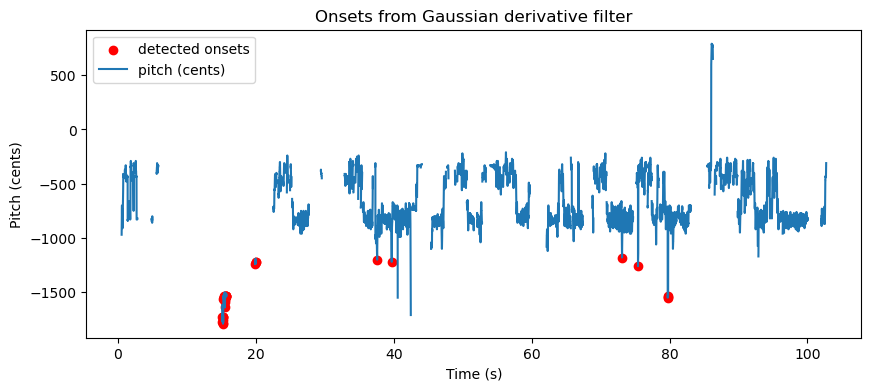

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))


plt.scatter(f0.time.iloc[pitch_drop_onsets],
            cents.iloc[pitch_drop_onsets],
            color="red",
            label="detected onsets")

plt.plot(f0.time, cents, label="pitch (cents)")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Pitch (cents)")
plt.title("Onsets from Gaussian derivative filter")
plt.show()

## All onsets

In [23]:
all_onsets = np.sort(np.concatenate([
    interval_onsets,
    gaussian_onsets,
    volume_onsets,
    pitch_drop_onsets
]))


merge_tol = int(0.05 / dt)  # frames

merged = [all_onsets[0]]

for o in all_onsets[1:]:
    
    if o - merged[-1] <= merge_tol:
        # same onset cluster → keep earliest
        continue
    
    merged.append(o)

merged_onsets = np.array(merged)

onset_times = f0.time.iloc[merged_onsets].values

Text(0.5, 1.0, 'Onsets from All the strategies')

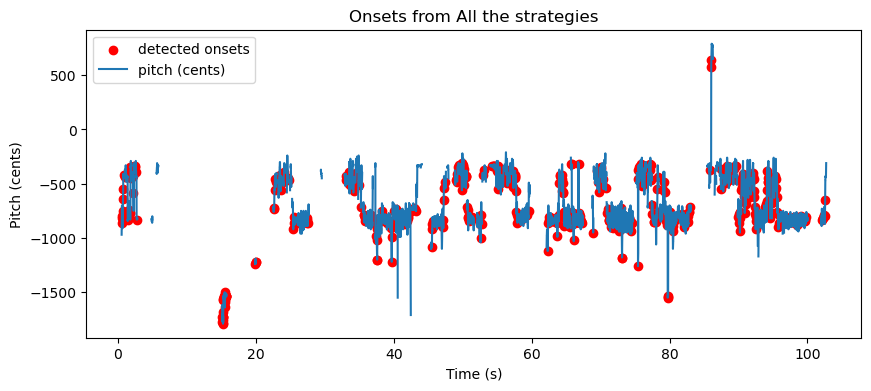

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))


plt.scatter(f0.time.iloc[all_onsets],
            cents.iloc[all_onsets],
            color="red",
            label="detected onsets")

plt.plot(f0.time, cents, label="pitch (cents)")

plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Pitch (cents)")
plt.title("Onsets from All the strategies")

## Note Transcritpion

In [3]:
from note_transcription import transcribe_notes, check_and_align_features
import matplotlib.pyplot as plt

import librosa
import numpy as np


In [4]:

################################
# ---- synthetic demo data ----
fs = 44100
hop_size = 128
hop_s = hop_size / fs
duration_s = 10.0
n_frames = int(duration_s / hop_s)

rng = np.random.default_rng(0)

# Simulate a voiced pitch contour: 3 notes with vibrato
f0 = np.zeros(n_frames)
note_freqs = [261.63, 293.66, 329.63]   # C4, D4, E4
note_starts = [int(0.5 / hop_s), int(3.5 / hop_s), int(6.5 / hop_s)]
note_ends   = [int(3.0 / hop_s), int(6.0 / hop_s), int(9.5 / hop_s)]


t = np.arange(n_frames) * hop_s
for freq, s, e in zip(note_freqs, note_starts, note_ends):
    vibrato = 1 + 0.005 * np.sin(2 * np.pi * 5.5 * t[s:e])
    f0[s:e] = freq * vibrato + rng.normal(0, 0.5, e - s)

# Simulate RMS (slight dip at note boundaries)
rms = 0.1 * np.ones(n_frames)
for s in note_starts:
    rms[max(0, s - 3) : s + 3] *= 0.3

# Simulate spectrum (random, used only for chroma)
n_fft = 2048
spectrum = np.abs(rng.normal(0, 0.1, (n_frames, n_fft // 2 + 1)))
for freq, s, e in zip(note_freqs, note_starts, note_ends):
    k = int(round(freq * n_fft / fs))
    spectrum[s:e, k] += 1.0
#########################################


# ---- run transcription ----
notes = transcribe_notes(f0, rms, spectrum, fs=fs, hop_size=hop_size)

In [5]:
import numpy as np
import pandas as pd
import librosa

# 1. Constants
fs = 44100
hop_size = 128

# 2. Load Audio & RMS
y, _ = librosa.load(audio_folder/ref_file.with_suffix(".wav"), sr=fs)
my_rms = librosa.feature.rms(y=y, frame_length=1024, hop_length=hop_size)[0]

# 3. Load F0 (Extracting the values into a 1D NumPy array)
# Assuming the CSV has time in col 0 and frequency in col 1
f0_df = pd.read_csv(f0auto_folder/ref_file.with_suffix(".f0.csv"), names=['time', 'f0_hz'])
f0_df = pd.read_csv(PESTO_f0_folder/ref_file.with_suffix(".f0.csv"))

my_f0 = f0_df['f0_hz'].to_numpy()

# 4. Load Spectrum
# Your synthetic spectrum was (n_frames, n_bins). 
# Most CSV exports are (n_bins, n_frames) or vice-versa.
spec_df = pd.read_csv(spec_folder/ref_file.with_suffix(".spectrum.csv"), sep=" ", header=None)
my_spec = spec_df.to_numpy()

# CRITICAL STEP: Shape Alignment
# Your synthetic data used shape (n_frames, n_bins). 
# If your CSV is (n_bins, n_frames), transpose it:
if my_spec.shape[0] < my_spec.shape[1]: 
    my_spec = my_spec.T

f0, rms, spectrum = check_and_align_features(
    f0_hz=my_f0,          rms=my_rms,         spectrum=my_spec,
    f0_hop=441,           rms_hop=128,         spectrum_hop=512,
    target_hop=128,       fs=44100,
)

Input durations:  f0=106.950s  rms=106.948s  spec=106.963s
After alignment:  all 36845 frames = 106.942s @ hop=128


In [6]:
# 5. Length Synchronization
# Different tools often result in slightly different frame counts (+/- 1 or 2 frames).
# We truncate everything to the shortest common length to prevent IndexErrors.
min_len = min(len(f0), len(rms), spectrum.shape[0])
f0 = f0[:min_len]
rms = rms[:min_len]
spectrum = spectrum[:min_len, :]
# ---- run transcription ----
notes = transcribe_notes(f0, rms, spectrum, fs=fs, hop_size=hop_size)

Transcribed notes:
 Onset (s)   Duration (s)   MIDI  Note name
    22.442          0.087     56        G#3
    22.529          0.093     62         D4
    22.500          0.070     62         D4
    22.750          0.116     66        F#4
    22.866          0.075     64         E4
    23.017          0.093     66        F#4
    23.110          0.113     66        F#4
    23.232          0.084     66        F#4
    23.316          0.096     66        F#4
    23.391          0.061     66        F#4
    23.452          0.087     66        F#4
    23.539          0.096     64         E4
    23.635          0.096     66        F#4
    23.731          0.215     66        F#4
    23.946          0.119     64         E4
    24.065          0.131     66        F#4
    24.195          0.075     66        F#4
    24.570          0.070     66        F#4
    24.639          0.096     66        F#4
    24.735          0.180     66        F#4
    24.915          0.093     63        D#4
    25.008   

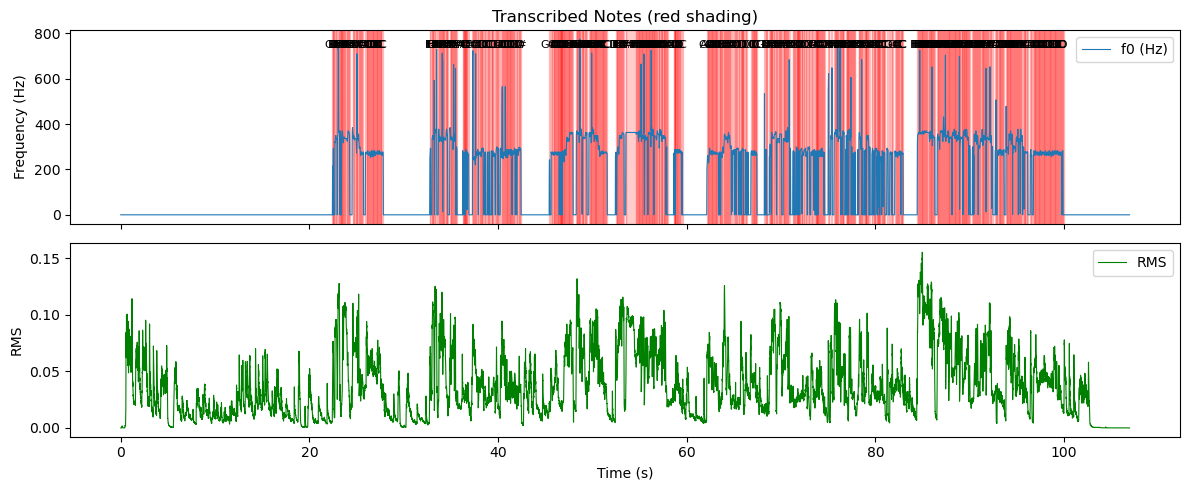

In [8]:
# ---- synthetic demo data ----
fs = 44100
hop_size = 128
hop_s = hop_size / fs
duration_s = len(y) / fs
n_frames = int(duration_s / hop_s)-1

print("Transcribed notes:")
print(f"{'Onset (s)':>10}  {'Duration (s)':>13}  {'MIDI':>5}  {'Note name':>9}")
note_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
for n in notes:
    name = note_names[n.midi % 12] + str(n.midi // 12 - 1)
    print(f"{n.onset:>10.3f}  {n.duration:>13.3f}  {n.midi:>5}  {name:>9}")

# ---- plot ----
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
t_frames = np.arange(n_frames) * hop_s

axes[0].plot(t_frames, f0, lw=0.8, label="f0 (Hz)")
for note in notes:
    axes[0].axvspan(note.onset, note.onset + note.duration, alpha=0.2, color="red")
    axes[0].text(note.onset + note.duration / 2, max(f0) * 0.95,
                    note_names[note.midi % 12], ha="center", fontsize=8)
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_title("Transcribed Notes (red shading)")
axes[0].legend()

axes[1].plot(t_frames, rms, lw=0.8, color="green", label="RMS")
axes[1].set_ylabel("RMS")
axes[1].set_xlabel("Time (s)")
axes[1].legend()

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/note_transcription_demo.png", dpi=150)
#print("\nPlot saved to note_transcription_demo.png")


In [9]:
import csv

# Output CSV file path
csv_path = Path("output_PESTO.notes.csv")

# Write CSV
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    for note in notes:
        # Convert onset and duration to float and format if needed
        writer.writerow([float(note.onset), float(note.duration), int(note.midi)])

print(f"Saved {len(notes)} notes to {csv_path}")

Saved 553 notes to output_PESTO.notes.csv


#### Onsets to notes

In [38]:
onsets = np.sort(all_onsets)

notes = []

for i in range(len(onsets)-1):

    start = onsets[i]
    end = onsets[i+1]

    segment = cents[start:end]

    segment = segment[~np.isnan(segment)]

    if len(segment) == 0:
        continue

    pitch = np.median(segment)
    hist, bins = np.histogram(segment, bins=120)
    pitch = bins[np.argmax(hist)]

    notes.append({
        "onset": f0.time.iloc[start],
        "duration": f0.time.iloc[end] - f0.time.iloc[start],
        "pitch_cents": pitch
    })


for note in notes:

    semitone = np.round(note["pitch_cents"] / 100)

    note["pitch_quantized_cents"] = semitone * 100

In [39]:
for note in notes:

    midi = 69 + (note["pitch_quantized_cents"] / 100)

    note["midi"] = int(midi)

In [40]:
merged = [notes[0]]

for n in notes[1:]:

    prev = merged[-1]

    if n["midi"] == prev["midi"]:
        prev["duration"] += n["duration"]
    else:
        merged.append(n)

notes = merged

In [41]:

notes_df = pd.DataFrame(notes)
notes_df.to_csv("testing_transcription_hist.csv")


## Another transcription

In [57]:
f0 = pesto_pred[['time_sec','f0_hz']].copy()
f0.rename(columns={'time_sec':'time', 'f0_hz':'f0'}, inplace=True)
f0.head()

f0 = f0_contour.copy()

In [58]:

f_ref = 440
f0_valid = f0.copy()
f0_valid.loc[f0_valid.f0 <= 0, "f0"] = np.nan
cents = 1200 * np.log2(f0_valid.f0 / f_ref)

In [59]:
from scipy.signal import medfilt

win = int(0.1 / dt)   # 100 ms
if win % 2 == 0:
    win += 1

c_smooth = medfilt(cents, win)

semi = c_smooth / 100

pitch_track = np.round(semi)

changes = np.where(np.diff(pitch_track) != 0)[0] + 1

onsets = np.concatenate(([0], changes))

In [61]:
import numpy as np

notes = []

for i in range(len(onsets)-1):
    start = onsets[i]
    end = onsets[i+1]

    # extract the pitch segment
    segment_pitch = pitch_track[start:end]

    # remove unvoiced frames (NaNs)
    voiced_pitch = segment_pitch[~np.isnan(segment_pitch)]

    # skip segment if no voiced frames
    if len(voiced_pitch) == 0:
        continue

    # compute a robust estimate of pitch (median works well)
    pitch_median = np.median(voiced_pitch)

    notes.append({
        "onset": f0.time.iloc[start],
        "duration": f0.time.iloc[end] - f0.time.iloc[start],
        "midi": int(round(69 + pitch_median))  # quantized to nearest semitone
    })

In [62]:
min_dur = 0.05  # 80 ms

notes = [n for n in notes if n["duration"] > min_dur]

In [ ]:
notes_df = pd.DataFrame(notes)
notes_df.to_csv("simple_transcription_f0Melodia.csv")

#### Mixed approach

In [81]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, convolve

def detect_interval_onsets(pitch_track, f0_time, delta_pmin=80, max_time_dist=0.25, fs=44100):
    """
    Detect interval onsets using local maxima of pitch contour (vibrato-insensitive)
    pitch_track: cent-scaled pitch track (np.array, NaN for unvoiced)
    f0_time: corresponding times (s)
    """
    # find local maxima
    local_maxima, _ = find_peaks(pitch_track, height=-np.inf)
    interval_onsets = []

    for i in range(len(local_maxima)-1):
        p1, p2 = pitch_track[local_maxima[i]], pitch_track[local_maxima[i+1]]
        dt = f0_time[local_maxima[i+1]] - f0_time[local_maxima[i]]
        if np.abs(p2 - p1) >= delta_pmin and dt <= max_time_dist:
            # onset approx centered between maxima
            onset_idx = int((local_maxima[i] + local_maxima[i+1]) / 2)
            interval_onsets.append(onset_idx)
    
    return interval_onsets

def detect_steady_onsets(pitch_track, audio_rms, N=4096, hop=128, voiced_thresh=-10, zmax=-2):
    """
    Detect steady pitch onsets from volume dips (RMS) and local pitch decreases
    pitch_track: cent-scaled pitch track (NaN for unvoiced)
    audio_rms: RMS array aligned with pitch_track
    """
    steady_onsets = []

    # 1. RMS local decay detection
    half_window = 50
    rLOC = 20 * np.log10(audio_rms / (np.convolve(audio_rms, np.ones(2*half_window+1)/(2*half_window+1), mode='same') + 1e-12))
    rms_dips = np.where(rLOC < voiced_thresh)[0]
    steady_onsets.extend(rms_dips.tolist())

    # 2. Pitch local minima detection (z-score)
    voiced_idx = ~np.isnan(pitch_track)
    if np.any(voiced_idx):
        c_voiced = pitch_track[voiced_idx]
        z = (c_voiced - np.mean(c_voiced)) / np.std(c_voiced)
        pitch_dips = np.where(z < zmax)[0]
        # map back to full index
        all_idx = np.arange(len(pitch_track))[voiced_idx]
        steady_onsets.extend(all_idx[pitch_dips].tolist())

    return list(sorted(set(steady_onsets)))

def gaussian_derivative_peaks(pitch_track, sigma=0.0435, fs=44100, min_peak=4.0):
    """
    Apply first derivative Gaussian to detect subtle pitch changes
    """
    Nc = len(pitch_track)
    N_sigma = int(np.round(6 * sigma * fs))
    n = np.arange(-N_sigma//2, N_sigma//2 + 1)
    h = -n / (sigma**2) * np.exp(-n**2 / (2*sigma**2))

    pitch_voiced = np.nan_to_num(pitch_track, nan=0.0)
    cF = convolve(pitch_voiced, h, mode='same')

    peaks, _ = find_peaks(np.abs(cF), height=min_peak)
    return peaks

def segment_notes(f0_df, audio_rms, fs=44100):
    """
    Full robust note segmentation and pitch quantization
    """
    # Convert f0 to cent scale (assuming reference 440 Hz)
    fRef = 440.0
    c0 = 1200 * np.log2(np.nan_to_num(f0.frequency, nan=fRef) / fRef)

    # 1. Detect all onset candidates
    interval_onsets = detect_interval_onsets(c0, f0.time.to_numpy(), fs=fs)
    steady_onsets = detect_steady_onsets(c0, audio_rms)
    derivative_peaks = gaussian_derivative_peaks(c0, fs=fs)

    # Merge all onsets
    merged_onsets = sorted(list(set(interval_onsets + steady_onsets + derivative_peaks.tolist())))

    # 2. Segment notes between merged onsets
    notes = []
    min_voiced_ratio = 0.5

    for i in range(len(merged_onsets)-1):
        start = merged_onsets[i]
        end = merged_onsets[i+1]
        segment_pitch = c0[start:end]
        voiced_pitch = segment_pitch[~np.isnan(segment_pitch)]

        if len(voiced_pitch) == 0:
            continue
        if len(voiced_pitch) / len(segment_pitch) < min_voiced_ratio:
            continue

        pitch_median = np.median(voiced_pitch)

        voiced_pitch = segment_pitch[~np.isnan(segment_pitch)]

        if len(voiced_pitch) == 0:
            # Skip this note segment because it's unvoiced
            continue

        pitch_median = np.median(voiced_pitch)
        midi_note = int(round(69 + pitch_median / 100))  # cent -> semitone

        notes.append({
            "onset": f0.time.iloc[start],
            "duration": f0.time.iloc[end] - f0.time.iloc[start],
            "midi": midi_note
})

    return notes

In [85]:
f0 = pesto_pred[['time_sec','f0_hz']].copy()
f0.rename(columns={'time_sec':'time', 'f0_hz':'frequency'}, inplace=True)
f0.loc[f0.frequency <= 0, "frequency"] = np.nan
f0.head()


,time,frequency
0,0.00,NaN
1,0.01,NaN
2,0.02,NaN
3,0.03,NaN
4,0.04,NaN


In [87]:
import librosa
import numpy as np

audio, sr = librosa.load(audio_folder/ref_file.with_suffix(".wav"), sr=44100)

import numpy as np

# audio: 1D numpy array of your waveform
fs = 44100
hop_size = int(0.01 * fs)  # 441 samples for 10 ms hop

num_frames = len(audio) // hop_size
rms = np.zeros(num_frames)

for i in range(num_frames):
    frame = audio[i*hop_size : i*hop_size + hop_size]
    rms[i] = np.sqrt(np.mean(frame**2))

print(len(rms))
notes = segment_notes(f0_df=f0, audio_rms=rms)

min_dur = 0.05  # 80 ms

notes = [n for n in notes if n["duration"] > min_dur]

10694


In [89]:
notes_df = pd.DataFrame(notes)
notes_df.to_csv("mixed_transcription_Pesto.csv")

In [ ]:
def noteToFreq(note):
    a = 440 #frequency of A (coomon value is 440Hz)
    return (a / 32) * (2 ** ((note - 9) / 12))

/tmp/ipykernel_26650/1387048557.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mu_vocal = np.mean(bark_energies[voiced_idx], axis=0)
/tmp/ipykernel_26650/1387048557.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cov_vocal = np.cov(bark_energies[voiced_idx], rowvar=False)
